# Exercise E3

This notebook to produce the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [25]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import cartopy.io.img_tiles as cimgt


## Exercise 1: South Pole

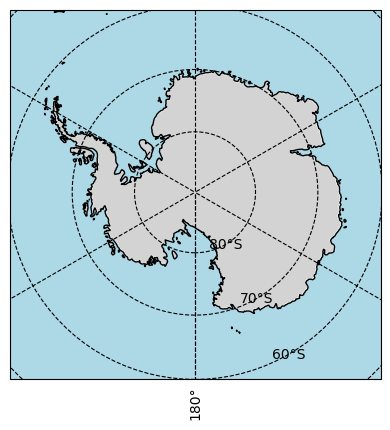

In [15]:
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Limit the map to 60°S and southwards
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
# Add gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--', color= 'black')
gl.top_labels = False
gl.right_labels = False

## Exercise 2

[Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


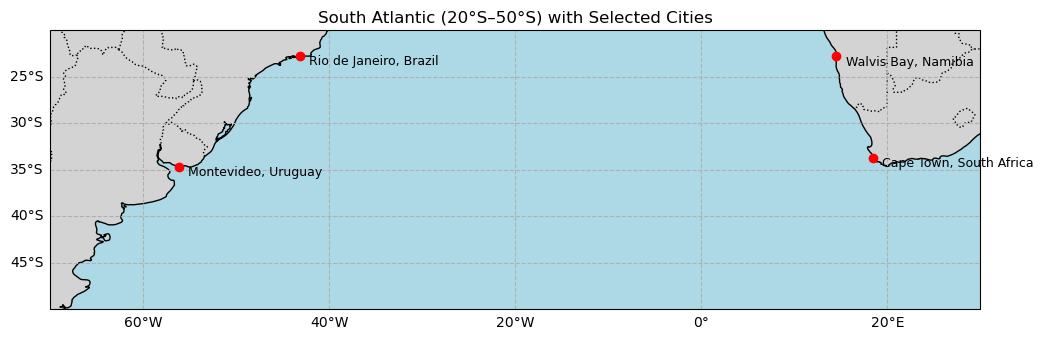

In [28]:
# Geolocator setup
geolocator = Nominatim(user_agent='educational')

# Map extent: South Atlantic region
extent = [-70, 30, -50, -20]   # [lon_min, lon_max, lat_min, lat_max]
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])

# Places to plot
place = ['Walvis Bay, Namibia', 'Cape Town, South Africa', 
         'Rio de Janeiro, Brazil', 'Montevideo, Uruguay']
address = []
for p in place:
    loc = geolocator.geocode(p, language="en")
    address.append(loc)
print(address)

# Plotting
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot each location
for p in range(len(place)):
    ax.plot(address[p].longitude, address[p].latitude, 'ro', markersize=6, transform=ccrs.Geodetic())
    ax.text(address[p].longitude + 1, address[p].latitude - 1, place[p], transform=ccrs.Geodetic(), fontsize=9)

plt.title("South Atlantic (20°S–50°S) with Selected Cities")
plt.show()
